# EDA tổng hợp sáu bộ dữ liệu glaucoma

Notebook này kiểm kê và so sánh dữ liệu trong thư mục data: GAMMA, HYDR, REFUGE, REFUGE2, DRISHTI-GS và PAPILA.

Mục tiêu là trả lời ba câu hỏi:

1. Mỗi bộ có bao nhiêu mẫu, loại ảnh, nhãn và chú thích nào?
2. Những bộ nào đủ tương đồng để so sánh trong cùng một bài toán nhị phân?
3. Chất lượng, nguồn ảnh, phân bố nhãn và trùng lặp dữ liệu gợi ý rủi ro hoặc hướng phân tích nào?

**Lưu ý về đơn vị mẫu:** số tệp ảnh không đồng nghĩa với số mẫu. GAMMA có các lát cắt OCT; REFUGE/REFUGE2 có thể chứa mask; những tệp này không được cộng như ảnh fundus độc lập. Các tỷ lệ nhãn dưới đây mô tả thành phần của bộ dữ liệu, không phải tỷ lệ mắc bệnh trong cộng đồng.

Chạy notebook từ thư mục gốc repo hoặc thư mục notebooks.


## 1. Thiết lập và tìm thư mục gốc

Notebook dùng pandas, matplotlib, seaborn, Pillow và openpyxl; các gói này đã có trong requirements.txt.


In [1]:
from pathlib import Path
from collections import Counter
import hashlib
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)

def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy repo có cả thư mục data/ và notebooks/.")

ROOT = find_repo_root()
DATA = ROOT / "data"
print("Repo:", ROOT)
print("Data:", DATA)


Repo: /home/dekii2275/Glaucoma-Detection
Data: /home/dekii2275/Glaucoma-Detection/data


## 2. Bản đồ dữ liệu và khả năng so sánh

Bảng mô tả bên dưới ghi nhận phạm vi nhãn và ghi chú cần nhớ khi so sánh. Hãy kiểm tra lại với tài liệu gốc nếu dùng số liệu trong báo cáo hoặc bài nghiên cứu.

- HYDR, DRISHTI-GS, PAPILA và REFUGE có trong manifest nhị phân dùng cho GONet.
- Manifest đó loại nhãn Suspect của PAPILA và không bao gồm GAMMA/REFUGE2.
- GAMMA giữ bài toán phân độ riêng. REFUGE2 trong bản local có ảnh trùng REFUGE và ảnh riêng chưa có nhãn glaucoma, theo README của repo.


In [2]:
dataset_notes = pd.DataFrame([
    {
        "dataset": "GAMMA",
        "modality_or_content": "Fundus và OCT; local tree có các thư mục ca và lát cắt",
        "label_scope": "non / early / mid_advanced",
        "common_binary_scope": "Phân tích riêng",
        "analysis_note": "Một ca có nhiều lát OCT; đếm ở cấp ca, không đếm lát cắt như bệnh nhân."
    },
    {
        "dataset": "HYDR",
        "modality_or_content": "Ảnh fundus; có bảng nhãn và điểm chất lượng",
        "label_scope": "GON+ / GON-",
        "common_binary_scope": "Có",
        "analysis_note": "Dùng Patient ID để thống kê và chia dữ liệu theo bệnh nhân."
    },
    {
        "dataset": "REFUGE",
        "modality_or_content": "Ảnh fundus; nhãn glaucoma và một số mask/chú thích",
        "label_scope": "Glaucoma / non-glaucoma",
        "common_binary_scope": "Có",
        "analysis_note": "Cần phân biệt ảnh fundus, ảnh mask và các split."
    },
    {
        "dataset": "REFUGE2",
        "modality_or_content": "Ảnh fundus và mask",
        "label_scope": "Chưa thấy nhãn glaucoma trong bản local",
        "common_binary_scope": "Không trong manifest hiện tại",
        "analysis_note": "Đo trùng chính xác với REFUGE trước khi xem là nguồn độc lập."
    },
    {
        "dataset": "DRISHTI-GS",
        "modality_or_content": "Ảnh fundus; nhãn theo thư mục lớp và chú thích cấu trúc",
        "label_scope": "Glaucoma / normal",
        "common_binary_scope": "Có",
        "analysis_note": "Kiểm tra class folder và annotation riêng biệt."
    },
    {
        "dataset": "PAPILA",
        "modality_or_content": "Ảnh fundus hai mắt và dữ liệu lâm sàng/contour",
        "label_scope": "Healthy / glaucoma / suspect",
        "common_binary_scope": "Có điều kiện",
        "analysis_note": "Manifest nhị phân loại suspect; mẫu hai mắt phải giữ chung theo bệnh nhân."
    },
])
display(dataset_notes)


,dataset,modality_or_content,label_scope,common_binary_scope,analysis_note
0,GAMMA,Fundus và OCT; local tree có các thư mục ca và lát cắt,non / early / mid_advanced,Phân tích riêng,"Một ca có nhiều lát OCT; đếm ở cấp ca, không đếm lát cắt như bệnh nhân."
1,HYDR,Ảnh fundus; có bảng nhãn và điểm chất lượng,GON+ / GON-,Có,Dùng Patient ID để thống kê và chia dữ liệu theo bệnh nhân.
2,REFUGE,Ảnh fundus; nhãn glaucoma và một số mask/chú thích,Glaucoma / non-glaucoma,Có,"Cần phân biệt ảnh fundus, ảnh mask và các split."
3,REFUGE2,Ảnh fundus và mask,Chưa thấy nhãn glaucoma trong bản local,Không trong manifest hiện tại,Đo trùng chính xác với REFUGE trước khi xem là nguồn độc lập.
4,DRISHTI-GS,Ảnh fundus; nhãn theo thư mục lớp và chú thích cấu trúc,Glaucoma / normal,Có,Kiểm tra class folder và annotation riêng biệt.
5,PAPILA,Ảnh fundus hai mắt và dữ liệu lâm sàng/contour,Healthy / glaucoma / suspect,Có điều kiện,Manifest nhị phân loại suspect; mẫu hai mắt phải giữ chung theo bệnh nhân.


## 3. Kiểm kê tệp

Số lượng ảnh raster trong bảng này chỉ là số tệp có đuôi ảnh. Nó có thể bao gồm lát OCT, mask và ảnh minh họa, nên không dùng làm số mẫu huấn luyện.


In [3]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
DATASET_DIRS = ["GAMMA", "HYDR", "REFUGE", "REFUGE2", "DRISHTI-GS", "PAPILA"]

def inventory_one(name):
    folder = DATA / name
    if not folder.is_dir():
        return {
            "dataset": name, "folder_exists": False, "all_files": 0,
            "raster_files_including_masks_or_slices": 0, "csv": 0, "xlsx": 0,
            "dicom": 0, "other_files": 0, "extensions": ""
        }
    files = [p for p in folder.rglob("*") if p.is_file() and "__MACOSX" not in p.parts]
    suffix_counts = Counter(p.suffix.lower() or "[no extension]" for p in files)
    raster_count = sum(n for suffix, n in suffix_counts.items() if suffix in IMAGE_SUFFIXES)
    return {
        "dataset": name,
        "folder_exists": True,
        "all_files": len(files),
        "raster_files_including_masks_or_slices": raster_count,
        "csv": suffix_counts.get(".csv", 0),
        "xlsx": suffix_counts.get(".xlsx", 0),
        "dicom": suffix_counts.get(".dcm", 0),
        "other_files": len(files) - raster_count - suffix_counts.get(".csv", 0) - suffix_counts.get(".xlsx", 0) - suffix_counts.get(".dcm", 0),
        "extensions": ", ".join(f"{k}: {v}" for k, v in sorted(suffix_counts.items()))
    }

inventory = pd.DataFrame([inventory_one(name) for name in DATASET_DIRS])
display(inventory)


,dataset,folder_exists,all_files,raster_files_including_masks_or_slices,csv,xlsx,dicom,other_files,extensions
0,GAMMA,True,26227,25701,0,1,512,13,".dcm: 512, .jpg: 25700, .md: 1, .mhd: 2, .pdf: 1, .raw: 2, .tif: 1, .xlsx: 1, .xml: 3,..."
1,HYDR,True,751,747,1,0,0,3,".csv: 1, .jpg: 747, .md: 1, .txt: 2"
2,REFUGE,True,3206,3203,0,3,0,0,".bmp: 1203, .jpg: 2000, .xlsx: 3"
3,REFUGE2,True,2400,2400,0,0,0,0,".bmp: 800, .jpg: 1200, .png: 400"
4,DRISHTI-GS,True,708,303,0,1,0,404,".png: 303, .txt: 404, .xlsx: 1"
5,PAPILA,True,2955,976,0,22,0,1957,".html: 1, .ini: 1, .ipynb: 1, .jpg: 976, .py: 1, .txt: 1953, .xlsx: 22"


## 4. Nạp manifest nhị phân đã chuẩn bị

Manifest là nguồn thống nhất để so sánh bốn miền có nhãn nhị phân. Cột label được quy ước 0 = GON−, 1 = GON+. Trước khi đọc biểu đồ, kiểm tra đường dẫn có tồn tại và xem những dataset nào thật sự có mặt trong manifest.


In [4]:
MANIFEST_PATH = DATA / "manifests" / "gonet_msd.csv"
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Không thấy {MANIFEST_PATH}. Chạy src/prepare_data.py hoặc cập nhật MANIFEST_PATH."
    )

manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {"image_path", "domain", "label", "patient_id"}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(f"Thiếu cột trong manifest: {sorted(missing_columns)}")

manifest["dataset"] = manifest["domain"].replace({"DRISHTI_GS": "DRISHTI-GS"})
manifest["label"] = pd.to_numeric(manifest["label"], errors="coerce")
manifest["abs_path"] = manifest["image_path"].map(lambda value: DATA / str(value))
manifest["patient_id"] = manifest["patient_id"].fillna("").astype(str)
manifest["class_name"] = manifest["label"].map({0: "GON-", 1: "GON+"})

print(f"Số dòng manifest: {len(manifest):,}")
print("Dataset trong manifest:", sorted(manifest["dataset"].unique()))
display(manifest.head())


Số dòng manifest: 2,468
Dataset trong manifest: ['DRISHTI-GS', 'HYDR', 'PAPILA', 'REFUGE']


,image_path,domain,label,patient_id,dataset,abs_path,class_name
0,DRISHTI-GS/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_001.png,DRISHTI_GS,1,DRISHTI_GS:drishtiGS_001,DRISHTI-GS,/home/dekii2275/Glaucoma-Detection/data/DRISHTI-GS/Test-20211018T060000Z-001/Test/Imag...,GON+
1,DRISHTI-GS/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_003.png,DRISHTI_GS,1,DRISHTI_GS:drishtiGS_003,DRISHTI-GS,/home/dekii2275/Glaucoma-Detection/data/DRISHTI-GS/Test-20211018T060000Z-001/Test/Imag...,GON+
2,DRISHTI-GS/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_005.png,DRISHTI_GS,1,DRISHTI_GS:drishtiGS_005,DRISHTI-GS,/home/dekii2275/Glaucoma-Detection/data/DRISHTI-GS/Test-20211018T060000Z-001/Test/Imag...,GON+
3,DRISHTI-GS/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_006.png,DRISHTI_GS,1,DRISHTI_GS:drishtiGS_006,DRISHTI-GS,/home/dekii2275/Glaucoma-Detection/data/DRISHTI-GS/Test-20211018T060000Z-001/Test/Imag...,GON+
4,DRISHTI-GS/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_011.png,DRISHTI_GS,1,DRISHTI_GS:drishtiGS_011,DRISHTI-GS,/home/dekii2275/Glaucoma-Detection/data/DRISHTI-GS/Test-20211018T060000Z-001/Test/Imag...,GON+


## 5. Phân bố nhãn trong các bộ có thể so sánh

Chỉ so sánh bốn nguồn cùng được ánh xạ vào nhãn nhị phân trong manifest. Khác biệt về tỷ lệ GON+ có thể đến từ cách tuyển mẫu, định nghĩa nhãn, bệnh viện hoặc thiết bị; không diễn giải là khác biệt tỷ lệ bệnh ngoài thực tế.


class_name,GON-,GON+,total,GON+ percent,minority / majority
dataset,,,,,
REFUGE,1080,120,1200,10.0,0.111
HYDR,199,548,747,73.4,0.363
PAPILA,333,87,420,20.7,0.261
DRISHTI-GS,31,70,101,69.3,0.443


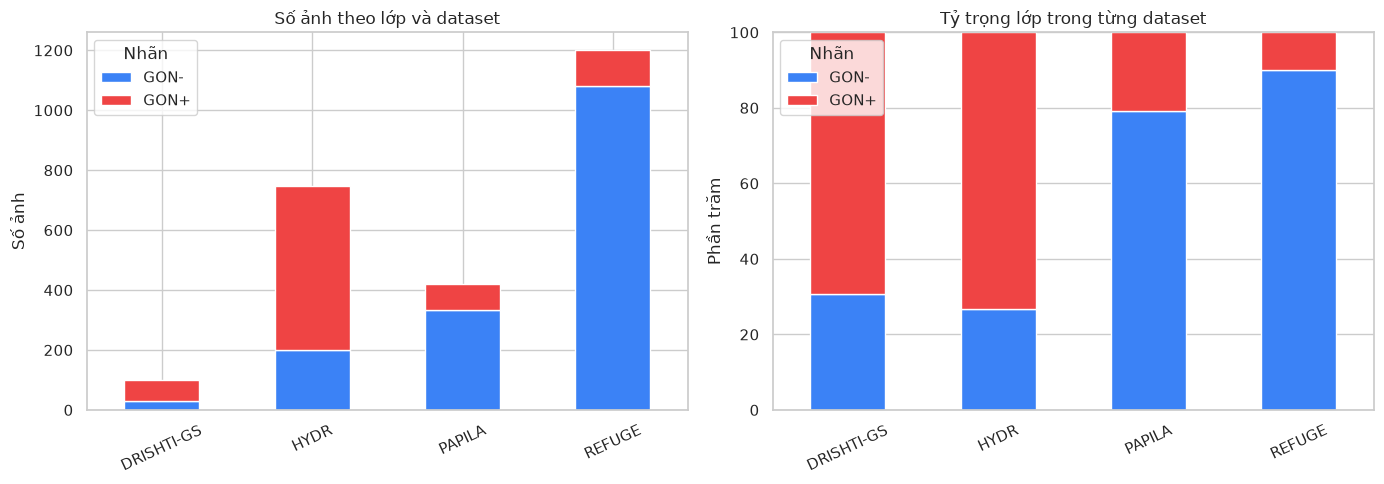

In [5]:
class_counts = (
    manifest.dropna(subset=["label"])
    .groupby(["dataset", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["GON-", "GON+"], fill_value=0)
)
class_summary = class_counts.copy()
class_summary["total"] = class_counts.sum(axis=1)
class_summary["GON+ percent"] = (100 * class_counts["GON+"] / class_summary["total"]).round(1)
class_summary["minority / majority"] = (
    class_counts.min(axis=1) / class_counts.max(axis=1).replace(0, np.nan)
).round(3)
display(class_summary.sort_values("total", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts.plot(kind="bar", stacked=True, color=["#3B82F6", "#EF4444"], ax=axes[0])
axes[0].set(title="Số ảnh theo lớp và dataset", xlabel="", ylabel="Số ảnh")
axes[0].legend(title="Nhãn")
axes[0].tick_params(axis="x", rotation=25)

class_props = class_counts.div(class_counts.sum(axis=1), axis=0) * 100
class_props.plot(kind="bar", stacked=True, color=["#3B82F6", "#EF4444"], ax=axes[1])
axes[1].set(title="Tỷ trọng lớp trong từng dataset", xlabel="", ylabel="Phần trăm")
axes[1].set_ylim(0, 100)
axes[1].legend(title="Nhãn")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# Tỷ lệ GON+ trong từng nguồn có nhãn nhị phân; mẫu số là ảnh trong manifest.
binary_order = [name for name in ["REFUGE", "PAPILA", "DRISHTI-GS", "HYDR"] if name in class_summary.index]
prevalence_values = class_summary.loc[binary_order, "GON+ percent"]
prevalence_labels = [f"{name} (n={int(class_summary.loc[name, 'total']):,})" for name in binary_order]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
y = np.arange(len(binary_order))
ax.barh(y, prevalence_values, color="#3B82F6", height=0.62)
ax.set_yticks(y, prevalence_labels)
ax.invert_yaxis()
ax.set_xlim(0, 85)
ax.set_xlabel("GON+ trong manifest (%)")
ax.set_title("Tỷ lệ GON+ khác nhau giữa các bộ fundus")
for yi, value in zip(y, prevalence_values):
    ax.text(value + 1, yi, f"{value:.1f}%", va="center", fontsize=9)
ax.grid(axis="x", color="#dddddd", linewidth=0.7)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.text(0.18, 0.02, "Tỷ lệ trong manifest; không đại diện prevalence ngoài cộng đồng.", fontsize=8, color="#555555")
fig.tight_layout(rect=(0, 0.06, 1, 1))
slide_chart_dir = ROOT / "outputs" / "eda_slides"
slide_chart_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(slide_chart_dir / "science_cross_dataset_label_mix.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()


### Gợi ý diễn giải

- Tỷ trọng GON+ khác nhau giữa các nguồn là một đặc điểm của mẫu hiện có, không phải ước lượng prevalence.
- Tỷ lệ lớp thiểu số/thống trị thấp báo hiệu accuracy có thể gây hiểu nhầm; khi đánh giá mô hình hãy xem thêm AUC, sensitivity, specificity và F1.
- Bảng này không bao gồm GAMMA vì đó là phân độ ba lớp; không bao gồm REFUGE2 vì bản local chưa có nhãn glaucoma tương ứng.


## 6. Phân tích số ảnh trên mỗi bệnh nhân

Chỉ có ý nghĩa với các hàng có patient_id. REFUGE không có crosswalk bệnh nhân trong manifest hiện tại nên không thể dùng thống kê này để khẳng định mỗi ảnh là một người khác nhau.


,patients,median_images_per_patient,max_images_per_patient,patients_with_multiple_images
dataset,,,,
DRISHTI-GS,101,1.0,1,0
HYDR,288,2.0,14,207
PAPILA,210,2.0,2,210


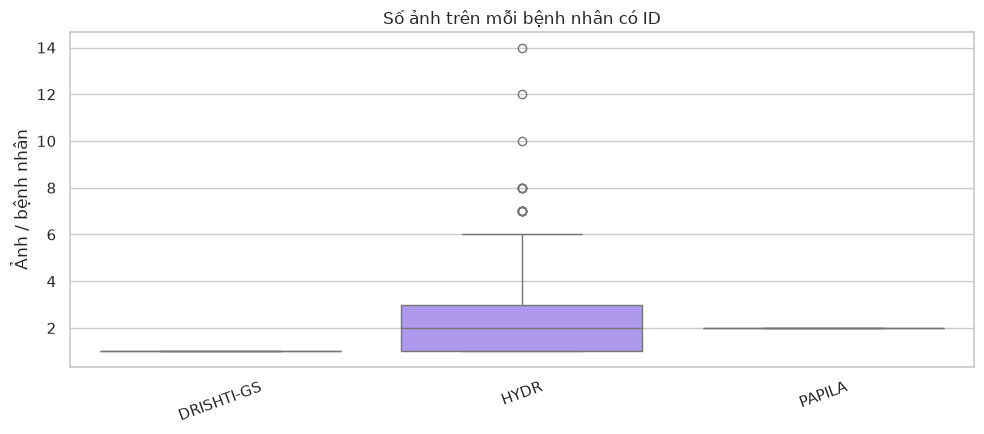

In [6]:
patient_rows = manifest[manifest["patient_id"].str.len() > 0].copy()
if patient_rows.empty:
    print("Không có patient_id trong manifest.")
else:
    per_patient = (
        patient_rows.groupby(["dataset", "patient_id"])
        .size()
        .rename("images_per_patient")
        .reset_index()
    )
    patient_summary = per_patient.groupby("dataset").agg(
        patients=("patient_id", "nunique"),
        median_images_per_patient=("images_per_patient", "median"),
        max_images_per_patient=("images_per_patient", "max"),
        patients_with_multiple_images=("images_per_patient", lambda s: int((s > 1).sum()))
    )
    display(patient_summary)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.boxplot(data=per_patient, x="dataset", y="images_per_patient", ax=ax, color="#A78BFA")
    ax.set(title="Số ảnh trên mỗi bệnh nhân có ID", xlabel="", ylabel="Ảnh / bệnh nhân")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()


## 7. Chất lượng ảnh HYDR

Điểm quality score được cung cấp trong bảng nhãn HYDR. Biểu đồ này mô tả điểm đã có sẵn, không phải một phép đo chất lượng mới do notebook tự suy ra.


Điểm chất lượng thiếu: 0


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
GON+,548.0,5.84,1.05,2.04,5.26,6.15,6.61,7.69
GON-,199.0,6.07,0.87,3.20,5.63,6.22,6.65,7.68


/tmp/ipykernel_192779/2877683759.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hydr_quality, x="Label", y="Quality Score", ax=ax, palette=["#EF4444", "#10B981"])


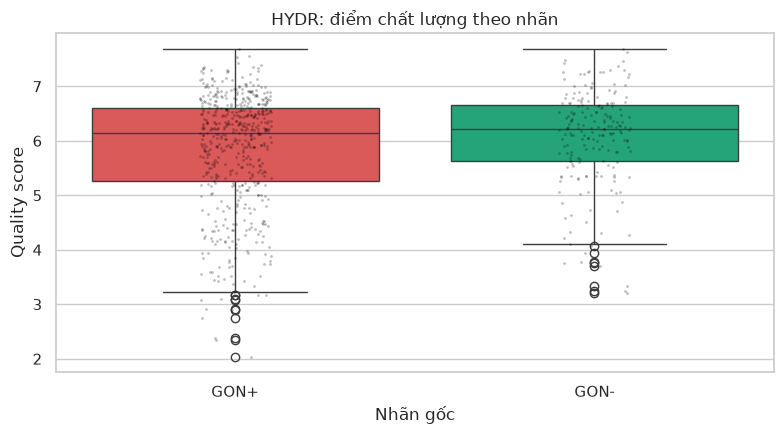

In [7]:
HYDR_LABELS = DATA / "HYDR" / "Labels.csv"
if HYDR_LABELS.is_file():
    hydr_raw = pd.read_csv(HYDR_LABELS, encoding="utf-8-sig")
    hydr_raw.columns = [str(c).strip() for c in hydr_raw.columns]
    expected = {"Image Name", "Label", "Quality Score"}
    if expected.issubset(hydr_raw.columns):
        hydr_quality = hydr_raw[["Image Name", "Label", "Quality Score"]].copy()
        hydr_quality["Quality Score"] = pd.to_numeric(hydr_quality["Quality Score"], errors="coerce")
        hydr_quality["Label"] = hydr_quality["Label"].astype(str).str.strip()
        print("Điểm chất lượng thiếu:", int(hydr_quality["Quality Score"].isna().sum()))
        display(hydr_quality.groupby("Label")["Quality Score"].describe().round(2))

        fig, ax = plt.subplots(figsize=(8, 4.5))
        sns.boxplot(data=hydr_quality, x="Label", y="Quality Score", ax=ax, palette=["#EF4444", "#10B981"])
        sns.stripplot(data=hydr_quality, x="Label", y="Quality Score", ax=ax, color="black", alpha=0.25, size=2)
        ax.set(title="HYDR: điểm chất lượng theo nhãn", xlabel="Nhãn gốc", ylabel="Quality score")
        plt.tight_layout()
        plt.show()
    else:
        print("Không khớp các cột Image Name / Label / Quality Score; kiểm tra lại file CSV.")
else:
    print("Không tìm thấy Labels.csv của HYDR.")


## 8. Kiểm tra tồn tại, đọc được và metadata ảnh

Notebook mở từng ảnh trong manifest để lấy kích thước, mode màu, định dạng và dung lượng; ảnh lỗi được ghi lại. Đây là bước kiểm tra dữ liệu, không áp dụng resize hay preprocessing.


In [8]:
image_records = []
image_errors = []

for row in manifest.itertuples(index=False):
    path = row.abs_path
    if not path.is_file():
        image_errors.append({"dataset": row.dataset, "image_path": row.image_path, "error": "missing"})
        continue
    try:
        with Image.open(path) as image:
            record = {
                "dataset": row.dataset,
                "image_path": row.image_path,
                "label": row.label,
                "width": image.width,
                "height": image.height,
                "mode": image.mode,
                "format": image.format,
                "bytes": path.stat().st_size,
                "aspect_ratio": image.width / image.height if image.height else np.nan,
            }
            image.verify()
        image_records.append(record)
    except Exception as exc:
        image_errors.append({
            "dataset": row.dataset,
            "image_path": row.image_path,
            "error": type(exc).__name__
        })

image_meta = pd.DataFrame(image_records)
image_errors = pd.DataFrame(image_errors)
print(f"Metadata đọc được: {len(image_meta):,}/{len(manifest):,}")
print(f"Thiếu hoặc lỗi: {len(image_errors):,}")
display(image_meta.groupby("dataset").agg(
    readable=("image_path", "count"),
    width_median=("width", "median"),
    height_median=("height", "median"),
    width_min=("width", "min"),
    width_max=("width", "max"),
    height_min=("height", "min"),
    height_max=("height", "max"),
    modes=("mode", lambda s: ", ".join(sorted(s.unique()))),
    formats=("format", lambda s: ", ".join(sorted(str(x) for x in s.unique())))
).round(1))
if not image_errors.empty:
    display(image_errors.head(20))


Metadata đọc được: 2,468/2,468
Thiếu hoặc lỗi: 0


,readable,width_median,height_median,width_min,width_max,height_min,height_max,modes,formats
dataset,,,,,,,,,
DRISHTI-GS,101,2049.0,1757.0,2045,2468,1748,1845,RGB,PNG
HYDR,747,1894.0,1894.0,1873,1960,1873,1960,RGB,"JPEG, PNG"
PAPILA,420,2576.0,1934.0,2576,2576,1934,1934,RGB,JPEG
REFUGE,1200,1634.0,1634.0,1634,2124,1634,2056,RGB,JPEG


## 9. So sánh kích thước ảnh

Nếu kích thước, tỷ lệ khung hình hoặc mode ảnh tách thành các cụm theo dataset, mô hình có thể chịu domain shift. Trước khi chuẩn hóa ảnh, cần quyết định preprocessing nhất quán và giữ lại ảnh gốc.


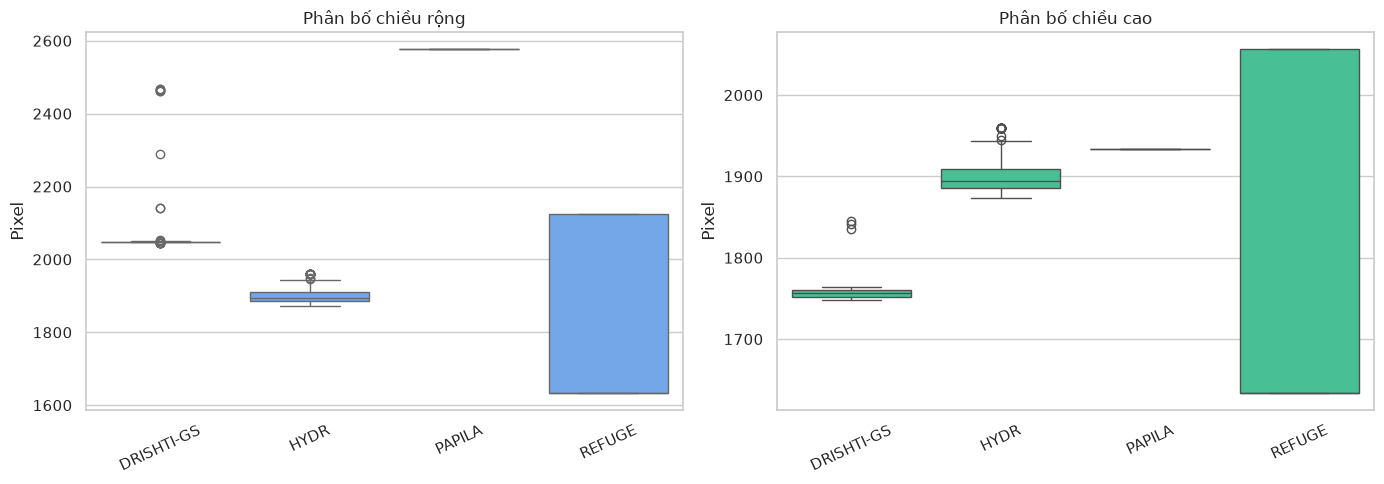

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
DRISHTI-GS,101.0,1.179,0.053,1.111,1.164,1.166,1.170,1.405
HYDR,747.0,1.000,0.000,1.000,1.000,1.000,1.000,1.000
PAPILA,420.0,1.332,0.000,1.332,1.332,1.332,1.332,1.332
REFUGE,1200.0,1.011,0.016,1.000,1.000,1.000,1.033,1.033


In [9]:
if not image_meta.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=image_meta, x="dataset", y="width", ax=axes[0], color="#60A5FA")
    axes[0].set(title="Phân bố chiều rộng", xlabel="", ylabel="Pixel")
    axes[0].tick_params(axis="x", rotation=25)

    sns.boxplot(data=image_meta, x="dataset", y="height", ax=axes[1], color="#34D399")
    axes[1].set(title="Phân bố chiều cao", xlabel="", ylabel="Pixel")
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

    display(image_meta.groupby("dataset")["aspect_ratio"].describe().round(3))


## 10. Xem ảnh mẫu theo dataset và nhãn

Ảnh được lấy từ manifest và hiển thị ở kích thước gốc. Mục đích là phát hiện khác biệt rõ về nền đen, crop, độ sáng, vị trí đĩa thị hoặc artefact; lưới mẫu không thay cho kiểm tra toàn bộ ảnh.


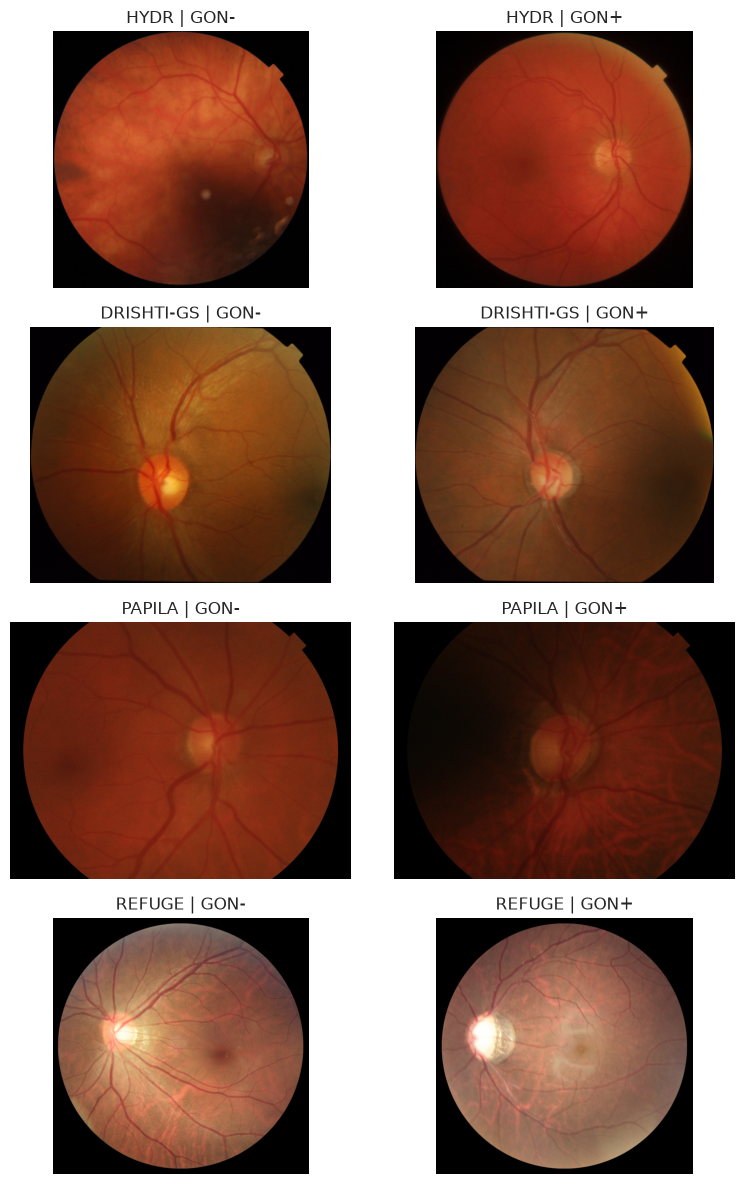

In [10]:
domains = [name for name in ["HYDR", "DRISHTI-GS", "PAPILA", "REFUGE"]
           if name in set(manifest["dataset"])]
fig, axes = plt.subplots(len(domains), 2, figsize=(8, max(3, 3 * len(domains))))
if len(domains) == 1:
    axes = np.array([axes])

for row_index, domain in enumerate(domains):
    for col_index, label in enumerate([0, 1]):
        subset = manifest[(manifest["dataset"] == domain) & (manifest["label"] == label)]
        ax = axes[row_index, col_index]
        if subset.empty:
            ax.set_title(f"{domain}: không có lớp {label}")
            ax.axis("off")
            continue
        sample = subset.sample(1, random_state=42).iloc[0]
        with Image.open(sample["abs_path"]) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{domain} | {sample['class_name']}")
        ax.axis("off")

plt.tight_layout()
plt.show()


## 11. Kiểm tra trùng ảnh chính xác giữa các nguồn có nhãn

SHA-256 tìm tệp có nội dung byte giống hệt nhau. Cách này không bắt được ảnh đã đổi kích thước/nén lại/crop; nếu cần kiểm tra sâu hơn có thể bổ sung perceptual hash và rà soát thủ công.


In [11]:
def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(chunk_size), b""):
            digest.update(block)
    return digest.hexdigest()

hash_records = []
for row in manifest.itertuples(index=False):
    path = row.abs_path
    if path.is_file():
        hash_records.append({
            "dataset": row.dataset,
            "image_path": row.image_path,
            "sha256": sha256_file(path)
        })

hash_df = pd.DataFrame(hash_records)
if hash_df.empty:
    duplicate_images = hash_df
else:
    duplicate_images = (
        hash_df[hash_df.duplicated("sha256", keep=False)]
        .sort_values(["sha256", "dataset"])
    )

print("Số nhóm hash bị lặp:", duplicate_images["sha256"].nunique() if not duplicate_images.empty else 0)
print("Số tệp nằm trong nhóm lặp:", len(duplicate_images))
if not duplicate_images.empty:
    display(duplicate_images.head(30))


Số nhóm hash bị lặp: 10
Số tệp nằm trong nhóm lặp: 20


,dataset,image_path,sha256
144,HYDR,HYDR/Images/110_1.jpg,0d5692ed6740ae09854ec55f90df0a7afae0f89b0bcca15279a3c635f6f9f2e2
792,HYDR,HYDR/Images/81_1.jpg,0d5692ed6740ae09854ec55f90df0a7afae0f89b0bcca15279a3c635f6f9f2e2
493,HYDR,HYDR/Images/239_0.jpg,242865ea54c7c0e1f948ac903de9c3b0b8460cf7e5bb5b23b203e26cb2ab50d6
534,HYDR,HYDR/Images/257_0.jpg,242865ea54c7c0e1f948ac903de9c3b0b8460cf7e5bb5b23b203e26cb2ab50d6
143,HYDR,HYDR/Images/110_0.jpg,255f5edfcb938651da7907d4697685608259dac9628d9574eb8f806ebebd2892
743,HYDR,HYDR/Images/65_5.jpg,255f5edfcb938651da7907d4697685608259dac9628d9574eb8f806ebebd2892
145,HYDR,HYDR/Images/110_2.jpg,27db6cc0651c28efe720ed242b8d74a9e3bdabb578d708d66cf9b9a88c653dad
791,HYDR,HYDR/Images/81_0.jpg,27db6cc0651c28efe720ed242b8d74a9e3bdabb578d708d66cf9b9a88c653dad
377,HYDR,HYDR/Images/187_0.jpg,2cebc8a350e2334b156338dfb829430182728748a163cb1d1d6bcf426d79ff8b
401,HYDR,HYDR/Images/197_0.jpg,2cebc8a350e2334b156338dfb829430182728748a163cb1d1d6bcf426d79ff8b


## 12. REFUGE2: kiểm tra mức chồng lấp chính xác với REFUGE

Đây là kiểm tra quan trọng trước khi xem REFUGE2 như một domain độc lập. Notebook so hash ảnh trong các thư mục images của REFUGE2 với ảnh REFUGE trong manifest. Các file mask không được đưa vào phép so sánh.


In [12]:
refuge2_root = DATA / "REFUGE2"
refuge_paths = manifest.loc[manifest["dataset"] == "REFUGE", "abs_path"].tolist()

if not refuge2_root.is_dir():
    print("Không có thư mục REFUGE2.")
elif not refuge_paths:
    print("Không có ảnh REFUGE trong manifest nên chưa thể đối chiếu.")
else:
    refuge_hashes = {
        sha256_file(path): path
        for path in refuge_paths if path.is_file()
    }
    refuge2_images = [
        path for path in refuge2_root.rglob("images/*")
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES and "__MACOSX" not in path.parts
    ]
    overlap_rows = []
    for path in refuge2_images:
        digest = sha256_file(path)
        overlap_rows.append({
            "refuge2_path": str(path.relative_to(DATA)),
            "sha256": digest,
            "exact_refuge_duplicate": digest in refuge_hashes,
            "matching_refuge_path": str(refuge_hashes[digest].relative_to(DATA)) if digest in refuge_hashes else ""
        })

    refuge2_overlap = pd.DataFrame(overlap_rows)
    if refuge2_overlap.empty:
        print("Không tìm thấy file ảnh trong các thư mục images/ của REFUGE2.")
    else:
        n_dup = int(refuge2_overlap["exact_refuge_duplicate"].sum())
        n_unique = len(refuge2_overlap) - n_dup
        print(f"REFUGE2 image files: {len(refuge2_overlap):,}")
        print(f"Exact duplicates of REFUGE: {n_dup:,}")
        print(f"Images without exact REFUGE match: {n_unique:,}")
        display(refuge2_overlap.head(10))


REFUGE2 image files: 1,200
Exact duplicates of REFUGE: 800
Images without exact REFUGE match: 400


,refuge2_path,sha256,exact_refuge_duplicate,matching_refuge_path
0,REFUGE2/REFUGE2/val/images/V0052.jpg,3dfacb8c9efbc8316f716a87e7b1d8c6f8bb4919a8ccce2187abcfa300bb1553,False,
1,REFUGE2/REFUGE2/val/images/V0098.jpg,ba97c014a42cdde33cd57d0af03566d00559e72094edb32387bef64da8fea92d,False,
2,REFUGE2/REFUGE2/val/images/V0306.jpg,d173144ba8b6a10619a98c6b9b33b7420ff2a00916cf8a939ede16c1bc185b70,False,
3,REFUGE2/REFUGE2/val/images/V0349.jpg,05aaa67dcea85a12b5d73dae1b74d5dcf261ee66b7ba5ef13ea38ef9df83f88a,False,
4,REFUGE2/REFUGE2/val/images/V0356.jpg,63a93c5f964ffdcae05b3fc7cc24e0e4f02bc7794e292270427927aec0565304,False,
5,REFUGE2/REFUGE2/val/images/V0223.jpg,00316cb4d1542f712f9afbe5b28cb0f167aeaf4e7ae7c33e30c94bc4ed833e30,False,
6,REFUGE2/REFUGE2/val/images/V0177.jpg,e820867ee9f603cacac3b1657dbe3c4bc1fb562d83ded3c7381d8c6c10228f1c,False,
7,REFUGE2/REFUGE2/val/images/V0242.jpg,b25cfef7b6dbdcd16eb61f85bd00e3a6c2ab3e1676c2db5499c70899356b05df,False,
8,REFUGE2/REFUGE2/val/images/V0205.jpg,524885812163c14ccea5d2738c554a4933f2269dfc22c022e7e4e917c6a77825,False,
9,REFUGE2/REFUGE2/val/images/V0168.jpg,b8452db52b42ab5adf4b137efd2b05ed74d8717f45176c6662c4ac5d1d40ba80,False,


## 13. GAMMA: đếm ở cấp ca và xem phân độ

GAMMA không thể cộng số JPEG OCT slice vào số ảnh fundus. Phần này đọc bảng ground truth của bản local, lấy mỗi thư mục ca làm một đơn vị, đếm lát cắt OCT riêng và so với số ca có nhãn.


Ca có thư mục: 100
Ca có nhãn: 100
Phân bố nhãn theo ca:


,cases
grade,
non,50
early,26
mid_advanced,24


,oct_jpeg_slices,dicom_files
count,100.0,100.0
mean,256.0,0.0
std,0.0,0.0
min,256.0,0.0
25%,256.0,0.0
50%,256.0,0.0
75%,256.0,0.0
max,256.0,0.0


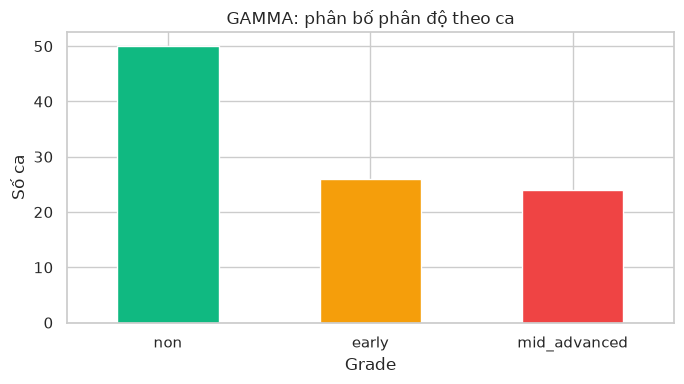

In [13]:
GAMMA_ROOT = DATA / "GAMMA"
GAMMA_CASE_ROOT = GAMMA_ROOT / "grading" / "Glaucoma_grading" / "training" / "multi-modality_images"
GAMMA_GT = GAMMA_ROOT / "grading" / "Glaucoma_grading" / "training" / "glaucoma_grading_training_GT.xlsx"

if GAMMA_GT.is_file() and GAMMA_CASE_ROOT.is_dir():
    gamma_gt = pd.read_excel(GAMMA_GT, dtype=str)
    gamma_gt.columns = [str(c).strip() for c in gamma_gt.columns]
    grade_columns = [c for c in ["non", "early", "mid_advanced"] if c in gamma_gt.columns]
    if "data" not in gamma_gt.columns or not grade_columns:
        print("Không nhận diện được cột data/non/early/mid_advanced trong ground truth.")
        gamma_cases = pd.DataFrame()
    else:
        gamma_gt["case_id"] = gamma_gt["data"].astype(str).str.strip().str.zfill(4)
        grade_values = gamma_gt[grade_columns].apply(pd.to_numeric, errors="coerce").fillna(0)
        gamma_gt["grade"] = grade_values.idxmax(axis=1)
        gamma_gt.loc[grade_values.sum(axis=1) == 0, "grade"] = pd.NA

        case_dirs = [
            path for path in GAMMA_CASE_ROOT.iterdir()
            if path.is_dir() and re.fullmatch(r"\d{4}", path.name)
        ]
        case_records = []
        for case_dir in case_dirs:
            case_records.append({
                "case_id": case_dir.name,
                "oct_jpeg_slices": len(list(case_dir.rglob("*_image.jpg"))),
                "dicom_files": len(list(case_dir.rglob("*.dcm"))),
                "has_raw_volume": any(case_dir.rglob("*.raw")),
                "has_mhd_header": any(case_dir.rglob("*.mhd")),
            })
        gamma_cases = pd.DataFrame(case_records).merge(
            gamma_gt[["case_id", "grade"]], on="case_id", how="left"
        )
        print("Ca có thư mục:", len(case_dirs))
        print("Ca có nhãn:", int(gamma_cases["grade"].notna().sum()))
        print("Phân bố nhãn theo ca:")
        display(gamma_cases["grade"].value_counts(dropna=False).rename("cases").to_frame())
        display(gamma_cases[["oct_jpeg_slices", "dicom_files"]].describe().round(1))

        gamma_grade_counts = gamma_cases["grade"].value_counts().reindex(grade_columns, fill_value=0)
        ax = gamma_grade_counts.plot(kind="bar", figsize=(7, 4), color=["#10B981", "#F59E0B", "#EF4444"])
        ax.set(title="GAMMA: phân bố phân độ theo ca", xlabel="Grade", ylabel="Số ca")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
else:
    print("Không tìm thấy ground truth hoặc thư mục multi-modality_images của GAMMA.")


### Diễn giải GAMMA

Phân bố trên là phân độ theo ca của phần dữ liệu hiện diện tại máy. Số lát OCT trên mỗi ca là số ảnh cắt/volume, không phải số bệnh nhân. Khi so sánh GAMMA với các bộ nhị phân, cần định nghĩa trước cách gộp grade và nêu rõ vì sao phép gộp đó hợp lý.


## 14. Tín hiệu cup/disc lặp lại giữa các bộ fundus

Phần này kiểm tra một đặc điểm giải phẫu có thể tính từ chú thích ở ba nguồn fundus có cả nhãn nhị phân và chú thích cup/disc: **REFUGE, DRISHTI-GS và PAPILA**. Chỉ số là diện tích cup chia diện tích optic disc. Vì cách chú thích khác nhau, không gộp số đo thô; thay vào đó, tính AUC riêng trong từng bộ để xem thứ hạng GON+ so với GON− có cùng chiều hay không.

Không thể áp dụng phép so sánh này cho cả sáu bộ: HYDR không có mask cup/disc trong bản local; REFUGE2 thiếu nhãn glaucoma độc lập và có ảnh trùng REFUGE; GAMMA dùng ảnh OCT và nhãn phân độ. Vì vậy, kết quả dưới đây là bằng chứng lặp lại trên ba nguồn, không phải kết luận từ cả sáu bộ.

**Giới hạn diễn giải:** nhãn glaucoma có thể đã dựa một phần vào hình thái đĩa thị, nên đây là mức độ liên hệ trong dữ liệu, không phải kiểm định chẩn đoán độc lập hay bằng chứng nhân quả.


In [ ]:
def polygon_area_file(path):
    points = np.loadtxt(path)
    x, y = points[:, 0], points[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

# REFUGE masks: grayscale 0=cup, 128=disc rim, 255=background.
refuge_cdr = []
for row in manifest.loc[manifest["dataset"] == "REFUGE"].itertuples(index=False):
    stem = Path(row.image_path).stem
    if "Training400" in row.image_path:
        class_dir = "Glaucoma" if int(row.label) == 1 else "Non-Glaucoma"
        mask_path = DATA / "REFUGE/Refuge/Annotation-Training400/Disc_Cup_Masks" / class_dir / f"{stem}.bmp"
    elif "Validation400" in row.image_path:
        mask_path = DATA / "REFUGE/Refuge/REFUGE-Validation400-GT/REFUGE-Validation400-GT/Disc_Cup_Masks" / f"{stem}.bmp"
    else:
        class_dir = "G" if int(row.label) == 1 else "N"
        mask_path = DATA / "REFUGE/Refuge/REFUGE-Test-GT/Disc_Cup_Masks" / class_dir / f"{stem}.bmp"
    mask = np.asarray(Image.open(mask_path).convert("L"))
    cup_area = np.count_nonzero(mask == 0)
    disc_rim_area = np.count_nonzero(mask == 128)
    refuge_cdr.append({"dataset": "REFUGE", "label": int(row.label), "area_cdr": cup_area / (cup_area + disc_rim_area), "sample_id": stem})

# DRISHTI-GS soft maps are binarized at 128 for both structures.
dr_softmaps = {path.name: path for path in (DATA / "DRISHTI-GS").rglob("*Softmap.png")}
drishti_cdr = []
for row in manifest.loc[manifest["dataset"] == "DRISHTI-GS"].itertuples(index=False):
    stem = Path(row.image_path).stem
    cup = np.asarray(Image.open(dr_softmaps[f"{stem}_cupsegSoftmap.png"])) >= 128
    disc = np.asarray(Image.open(dr_softmaps[f"{stem}_ODsegSoftmap.png"])) >= 128
    drishti_cdr.append({"dataset": "DRISHTI-GS", "label": int(row.label), "area_cdr": cup.sum() / disc.sum(), "sample_id": stem})

# PAPILA: mean area ratio across two experts per eye, then mean across eyes per patient.
papila_roots = [path for path in (DATA / "PAPILA").rglob("Contours") if path.is_dir()]
if not papila_roots:
    raise FileNotFoundError("Không tìm thấy thư mục ExpertsSegmentations/Contours của PAPILA.")
papila_contours = papila_roots[0]
papila_eye_rows = []
for row in manifest.loc[manifest["dataset"] == "PAPILA"].itertuples(index=False):
    stem = Path(row.image_path).stem
    expert_ratios = []
    for expert in (1, 2):
        cup_file = papila_contours / f"{stem}_cup_exp{expert}.txt"
        disc_file = papila_contours / f"{stem}_disc_exp{expert}.txt"
        expert_ratios.append(polygon_area_file(cup_file) / polygon_area_file(disc_file))
    papila_eye_rows.append({
        "patient_id": row.patient_id,
        "label": int(row.label),
        "area_cdr": float(np.mean(expert_ratios)),
    })
papila_eyes = pd.DataFrame(papila_eye_rows)
papila_patients = []
for patient_id, group in papila_eyes.groupby("patient_id"):
    # Exclude the 7 patients whose two binary-labeled eyes have conflicting labels.
    if group["label"].nunique() == 1:
        papila_patients.append({
            "dataset": "PAPILA",
            "label": int(group["label"].iloc[0]),
            "area_cdr": group["area_cdr"].mean(),
            "sample_id": patient_id,
        })


def auc_from_scores(labels, scores):
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)
    positive = scores[labels == 1]
    negative = np.sort(scores[labels == 0])
    less = np.searchsorted(negative, positive, side="left")
    less_or_equal = np.searchsorted(negative, positive, side="right")
    return (less.sum() + 0.5 * (less_or_equal - less).sum()) / (len(positive) * len(negative))


def bootstrap_auc_ci(frame, seed, n_boot=5000):
    positive = frame.loc[frame["label"] == 1, "area_cdr"].to_numpy()
    negative = frame.loc[frame["label"] == 0, "area_cdr"].to_numpy()
    point = auc_from_scores(frame["label"], frame["area_cdr"])
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        boot_pos = rng.choice(positive, size=len(positive), replace=True)
        boot_neg = rng.choice(negative, size=len(negative), replace=True)
        boot[i] = auc_from_scores(
            np.r_[np.ones(len(boot_pos)), np.zeros(len(boot_neg))],
            np.r_[boot_pos, boot_neg],
        )
    lo, hi = np.quantile(boot, [0.025, 0.975])
    return len(positive), len(negative), point, lo, hi


cdr_frames = {
    "REFUGE": pd.DataFrame(refuge_cdr),
    "DRISHTI-GS": pd.DataFrame(drishti_cdr),
    "PAPILA": pd.DataFrame(papila_patients),
}
summary_rows = []
for seed, (dataset, frame) in enumerate(cdr_frames.items(), start=10):
    n_positive, n_negative, auc, ci_low, ci_high = bootstrap_auc_ci(frame, seed)
    summary_rows.append({
        "dataset": dataset,
        "unit": "patients" if dataset == "PAPILA" else "images",
        "GON+": n_positive,
        "GON-": n_negative,
        "AUC": auc,
        "95% CI low": ci_low,
        "95% CI high": ci_high,
        "median area CDR, GON+": frame.loc[frame["label"] == 1, "area_cdr"].median(),
        "median area CDR, GON-": frame.loc[frame["label"] == 0, "area_cdr"].median(),
    })
cdr_summary = pd.DataFrame(summary_rows)
display(cdr_summary.round(3))

fig, ax = plt.subplots(figsize=(10.8, 4.3))
fig.subplots_adjust(left=0.32, right=0.80, bottom=0.20, top=0.88)
y_positions = np.arange(len(cdr_summary))[::-1]
plot_labels = []
for y, row in zip(y_positions, cdr_summary.itertuples(index=False)):
    ci_low, ci_high = row[5], row[6]
    ax.errorbar(
        row.AUC, y,
        xerr=[[row.AUC - ci_low], [ci_high - row.AUC]],
        fmt="o", color="#245A85", ecolor="#245A85", capsize=3, markersize=6, linewidth=1.6,
    )
    ax.text(1.02, y, f"{row.AUC:.2f} [{ci_low:.2f}, {ci_high:.2f}]", va="center", fontsize=9, clip_on=False)
    unit = "patients" if row.dataset == "PAPILA" else "images"
    plot_labels.append(f"{row.dataset} ({row[2]} GON+, {row[3]} GON- {unit})")
ax.set_yticks(y_positions, plot_labels)
ax.axvline(0.5, color="#777777", linestyle="--", linewidth=1)
ax.set_xlim(0.5, 1.0)
ax.set_ylim(-0.6, len(cdr_summary) - 0.4)
ax.set_xticks(np.arange(0.5, 1.01, 0.1))
ax.set_xlabel("AUC (0,5 = ngẫu nhiên)")
ax.set_title("Chỉ số cup/disc phân tách nhãn glaucoma ở 3 bộ fundus")
ax.grid(axis="x", color="#dddddd", linewidth=0.7)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=9)
fig.text(0.32, 0.04, "AUC tính riêng từng bộ; KTC bootstrap 95%. PAPILA gộp hai mắt theo bệnh nhân.", fontsize=8, color="#555555")
chart_dir = ROOT / "outputs" / "eda_slides"
chart_dir.mkdir(parents=True, exist_ok=True)
chart_path = chart_dir / "science_cross_dataset_area_cdr_auc.png"
fig.savefig(chart_path, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Biểu đồ:", chart_path)


## 15. Tự động tạo các insight ứng viên

Các câu dưới đây là gợi ý dựa trên số liệu đọc được. Hãy giữ lại kết luận khi đã kiểm tra bảng/biểu đồ và giải thích được nguyên nhân có thể; EDA không xác lập nguyên nhân hay quan hệ nhân quả.


In [14]:
insight_candidates = []

if not class_summary.empty:
    largest = class_summary["total"].idxmax()
    smallest = class_summary["total"].idxmin()
    insight_candidates.append({
        "evidence": f"{largest} có {int(class_summary.loc[largest, 'total']):,} ảnh; "
                    f"{smallest} có {int(class_summary.loc[smallest, 'total']):,} ảnh trong manifest.",
        "candidate_interpretation": "Kích thước nguồn khác nhau; cân nhắc báo cáo metric riêng theo domain và bootstrap CI."
    })

    prevalence = class_summary["GON+ percent"].dropna()
    if len(prevalence) >= 2:
        low_domain, high_domain = prevalence.idxmin(), prevalence.idxmax()
        gap = prevalence.max() - prevalence.min()
        insight_candidates.append({
            "evidence": f"Tỷ trọng GON+ trong manifest dao động từ {prevalence.min():.1f}% "
                        f"({low_domain}) đến {prevalence.max():.1f}% ({high_domain}), "
                        f"chênh {gap:.1f} điểm phần trăm.",
            "candidate_interpretation": "Khác biệt có thể phản ánh cách chọn mẫu/nhãn; không diễn giải là prevalence cộng đồng."
        })

    imbalanced = class_summary["minority / majority"].idxmin()
    insight_candidates.append({
        "evidence": f"{imbalanced} có tỷ lệ lớp thiểu số/thống trị thấp nhất "
                    f"({class_summary.loc[imbalanced, 'minority / majority']:.3f}).",
        "candidate_interpretation": "Không nên chỉ dùng accuracy; báo cáo sensitivity, specificity, AUC và F1."
    })

if not image_meta.empty:
    medians = image_meta.groupby("dataset")[["width", "height"]].median()
    width_range = medians["width"].max() - medians["width"].min()
    height_range = medians["height"].max() - medians["height"].min()
    insight_candidates.append({
        "evidence": f"Chênh giữa median width lớn nhất/nhỏ nhất là {width_range:.0f}px; "
                    f"median height là {height_range:.0f}px.",
        "candidate_interpretation": "Kiểm tra domain shift do kích thước, crop, thiết bị và preprocessing."
    })

if len(image_errors):
    insight_candidates.append({
        "evidence": f"Có {len(image_errors):,} đường dẫn thiếu hoặc ảnh lỗi trong manifest.",
        "candidate_interpretation": "Sửa manifest hoặc ghi rõ loại bỏ mẫu trước khi huấn luyện."
    })

if "refuge2_overlap" in globals() and not refuge2_overlap.empty:
    n_dup = int(refuge2_overlap["exact_refuge_duplicate"].sum())
    insight_candidates.append({
        "evidence": f"REFUGE2 có {n_dup:,}/{len(refuge2_overlap):,} ảnh trùng byte với REFUGE.",
        "candidate_interpretation": "Không coi ảnh trùng là domain độc lập; tránh rò rỉ giữa train và test."
    })

if "gamma_cases" in globals() and not gamma_cases.empty:
    insight_candidates.append({
        "evidence": f"GAMMA có {int(gamma_cases['grade'].notna().sum()):,} ca có nhãn trong bản local; "
                    f"median lát OCT JPEG/ca là {gamma_cases['oct_jpeg_slices'].median():.0f}.",
        "candidate_interpretation": "Phân tích GAMMA ở cấp ca/grade; không so số lát OCT với số ảnh fundus."
    })

insights = pd.DataFrame(insight_candidates)
display(insights)


,evidence,candidate_interpretation
0,"REFUGE có 1,200 ảnh; DRISHTI-GS có 101 ảnh trong manifest.",Kích thước nguồn khác nhau; cân nhắc báo cáo metric riêng theo domain và bootstrap CI.
1,"Tỷ trọng GON+ trong manifest dao động từ 10.0% (REFUGE) đến 73.4% (HYDR), chênh 63.4 đ...",Khác biệt có thể phản ánh cách chọn mẫu/nhãn; không diễn giải là prevalence cộng đồng.
2,REFUGE có tỷ lệ lớp thiểu số/thống trị thấp nhất (0.111).,"Không nên chỉ dùng accuracy; báo cáo sensitivity, specificity, AUC và F1."
3,Chênh giữa median width lớn nhất/nhỏ nhất là 942px; median height là 300px.,"Kiểm tra domain shift do kích thước, crop, thiết bị và preprocessing."
4,"REFUGE2 có 800/1,200 ảnh trùng byte với REFUGE.",Không coi ảnh trùng là domain độc lập; tránh rò rỉ giữa train và test.
5,GAMMA có 100 ca có nhãn trong bản local; median lát OCT JPEG/ca là 256.,Phân tích GAMMA ở cấp ca/grade; không so số lát OCT với số ảnh fundus.


## 16. Kết luận và checklist viết báo cáo

Khi viết phần kết quả EDA, mỗi insight nên có cấu trúc:

**Quan sát định lượng → bằng chứng/biểu đồ → ý nghĩa cho thiết kế thí nghiệm.**

Checklist trước khi chốt:

- Ghi rõ đơn vị đếm: bệnh nhân, mắt, ảnh fundus, ca OCT hay lát cắt.
- Nêu số liệu và tỷ lệ lớp theo từng dataset; không chỉ nêu tổng.
- Mô tả quy tắc chuẩn hóa nhãn và các lớp bị loại, nhất là Suspect của PAPILA.
- Tách GAMMA khỏi bảng binary cho đến khi giải thích rõ cách gộp grade.
- Báo cáo REFUGE2 trùng với REFUGE và không xem ảnh chưa có nhãn glaucoma như dữ liệu có nhãn.
- Nếu một bệnh nhân có nhiều ảnh/hai mắt, chia train-validation-test theo bệnh nhân.
- Phân biệt khác biệt do nguồn dữ liệu với khác biệt do bệnh; không suy ra nguyên nhân chỉ từ biểu đồ.
- Với các bộ nhỏ, ưu tiên trình bày số lượng và khoảng tin cậy khi đánh giá mô hình; EDA mô tả không thay cho kiểm định hay xác nhận lâm sàng.

Notebook chỉ làm EDA và kiểm tra cấu trúc. Nó không tự sửa ảnh, gộp nhãn, lọc chất lượng hay quyết định split huấn luyện.
